### **Capstone Project: Predicting Employee Turnover to Drive HR Retention Strategies**

#### **Executive Summary & Business Scenario**
Salifort Motors, a large global consulting firm, is currently experiencing an unusually high rate of employee turnover. High attrition is significantly impacting the company's bottom line through increased recruitment costs, lost productivity during onboarding, and diminished team morale. 

The HR department has compiled an extensive dataset of employee metrics—ranging from satisfaction levels and performance evaluations to workload and tenure—and has commissioned this analysis to transition from a reactive replacement approach to a proactive retention strategy.

#### **The Problem Statement**
Leadership currently lacks visibility into the underlying causes of employee attrition. Without understanding *why* employees leave or *who* is at the highest risk of resigning in the near future, HR cannot effectively allocate resources to retain top talent.

#### **Business Objective**
The primary objective of this project is to develop a predictive machine learning model that identifies employees at high risk of leaving the company. Furthermore, the model will be used to extract feature importances, uncovering the core drivers of turnover to provide actionable, data-driven recommendations for the executive team.

#### **Key Analytical Questions**
To achieve the business objective, this project will address the following key questions:
1. **What are the primary drivers of employee turnover at Salifort Motors?** (e.g., Is it compensation, workload, or job satisfaction?)
2. **Are there specific employee segments (by department, salary, or tenure) that are disproportionately at risk?**
3. **Can we accurately predict which current employees will leave, minimizing false negatives (failing to identify a flight risk)?**
4. **What immediate, strategic interventions can HR implement to improve overall retention?**

#### **Methodology (PACE Framework)**
This project follows the **PACE** (Plan, Analyze, Construct, Execute) workflow:
* **Plan:** Define the scope, business goals, and framing of the analysis.
* **Analyze:** Perform Exploratory Data Analysis (EDA) to discover trends, anomalies, and relationships within the HR dataset.
* **Construct:** Preprocess the data and engineer a robust Machine Learning model (Random Forest Classifier) to predict attrition.
* **Execute:** Evaluate model performance, extract business insights, and synthesize final recommendations for stakeholders.

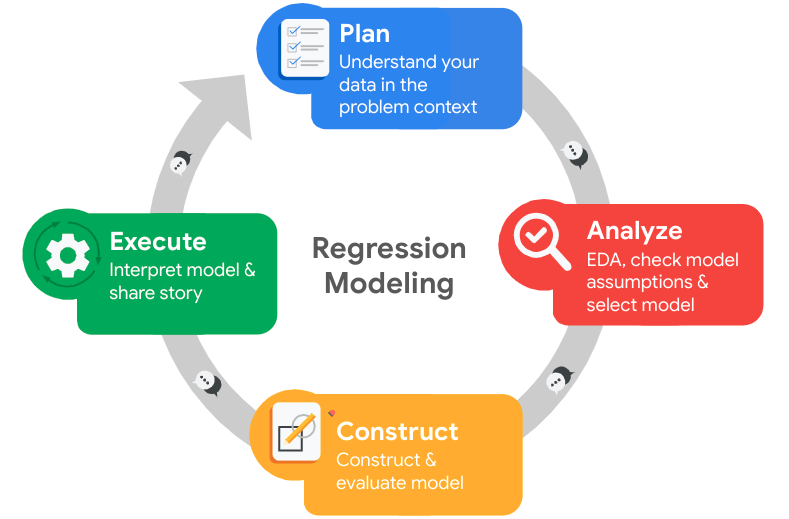

#### **PACE: Plan**
**Objective:** The goal of this project is to analyze the `HR_capstone_dataset.csv` to identify the key drivers of employee turnover and build a predictive model. By predicting whether an employee is likely to leave the company, the HR department at Salifort Motors can take proactive, data-driven steps to improve retention, enhance job satisfaction, and reduce recruitment costs.

**Deliverables:**
* Exploratory Data Analysis (EDA) uncovering turnover trends.
* A machine learning model (Random Forest Classifier) to predict turnover.
* Actionable recommendations for the HR and executive teams.

#### Import packages

In [2]:
# Import essential libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

#### **PACE: Analyze**
In this stage, we will load the dataset, check for data quality issues (missing values, duplicates, outliers), and perform Exploratory Data Analysis (EDA) to understand the distribution of the data and the relationships between features and the target variable (`left`).

In [3]:
# Load the dataset
df = pd.read_csv('HR_capstone_dataset.csv')

# Display the first few rows of the dataframe
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
# Gather basic information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [5]:
# Gather descriptive statistics about the data
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [6]:
# Check for missing values
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [7]:
# Check for duplicates
df.duplicated().sum()

np.int64(3008)

We have identified 3008 duplicated rows in the dataset. We will **remove** it as without a unique identifier like `Employee_ID`, identical rows likely represent data entry errors rather than two identical employees.

Furthermore, leaving duplicates in the dataset can lead to biased predictions from overweighting specific employee profiles.

In [8]:
# Drop duplicates to ensure model accuracy
df = df.drop_duplicates().reset_index(drop=True)

# Check that there are no duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# Display all column names
df.columns

# Rename columns as needed to standardize to snake_case
df = df.rename(columns={
    'Work_accident': 'work_accident',
    'Department': 'department',
    'time_spend_company': 'tenure'
})

# Display all column names after the update
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

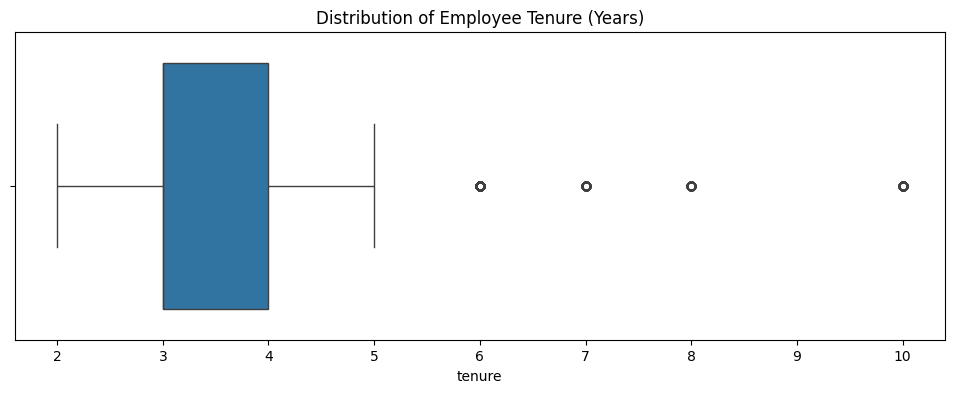

In [10]:
# Create a boxplot to visualize distribution of `tenure` (time_spend_company) and detect any outliers
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['tenure'])
plt.title('Distribution of Employee Tenure (Years)')
plt.savefig('tenure_distribution.png', bbox_inches='tight', dpi=300)
plt.show()


The `tenure` variable exhibits right-skewed distribution as there are a few employees staying for >5 years with the company. As these represent true historical data of senior employees that is valuable data, we will keep them for modeling.

#### Exploratory Data Analytics (EDA)

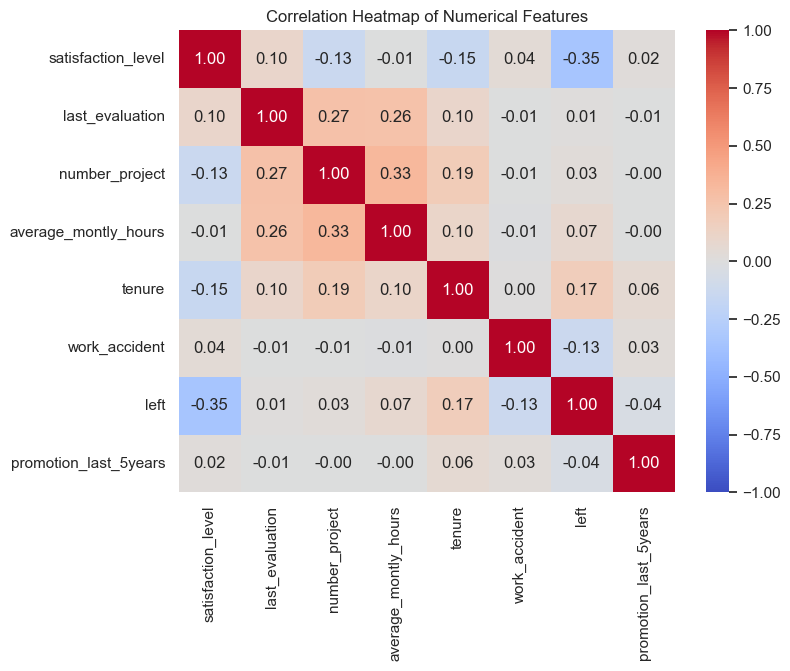

In [11]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()


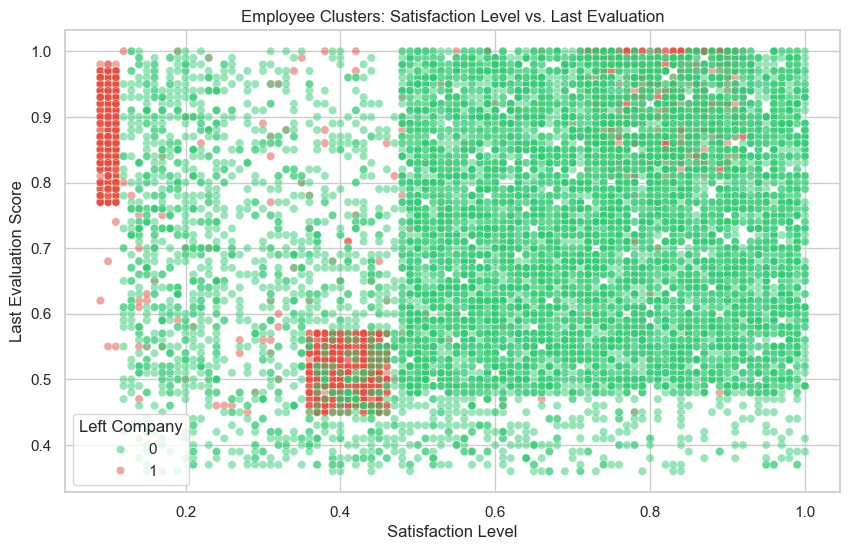

In [12]:
# Scatterplot: Satisfaction vs. Evaluation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='left', alpha=0.5, palette=['#2ecc71', '#e74c3c'])
plt.title('Employee Clusters: Satisfaction Level vs. Last Evaluation')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation Score')
plt.legend(title='Left Company')
plt.savefig('satisfaction_eval_scatter.png', bbox_inches='tight', dpi=300)
plt.show()

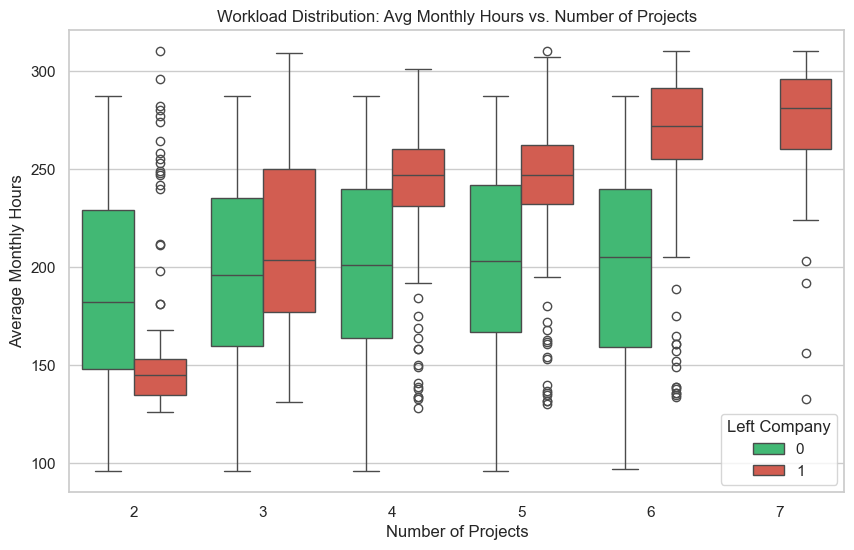

In [13]:
# Boxplot: Monthly Hours by Number of Projects
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='number_project', y='average_montly_hours', hue='left', palette=['#2ecc71', '#e74c3c'])
plt.title('Workload Distribution: Avg Monthly Hours vs. Number of Projects')
plt.xlabel('Number of Projects')
plt.ylabel('Average Monthly Hours')
plt.legend(title='Left Company')
plt.savefig('workload_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

<Axes: xlabel='salary', ylabel='left'>

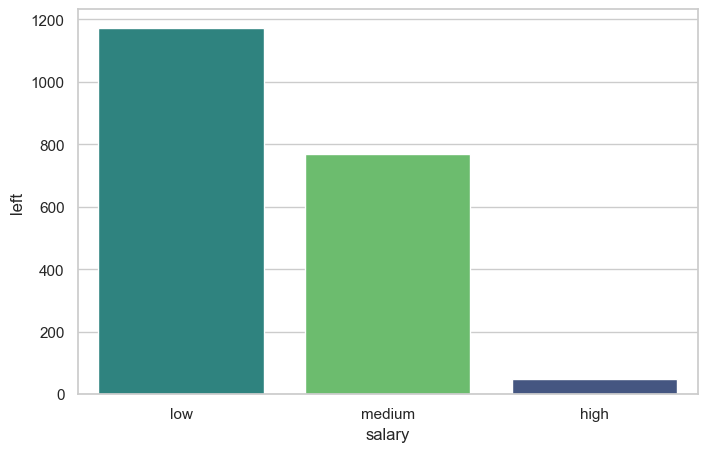

In [14]:
# Bar Plot: Turnover Rate by Salary Level
plt.figure(figsize=(8, 5))
# Calculate the percentage of people who left per salary tier
salary_turnover = df.groupby('salary')['left'].sum().reset_index()

sns.barplot(data=salary_turnover, x='salary', y='left', order=['low', 'medium', 'high'], hue='salary', palette='viridis', legend=False)

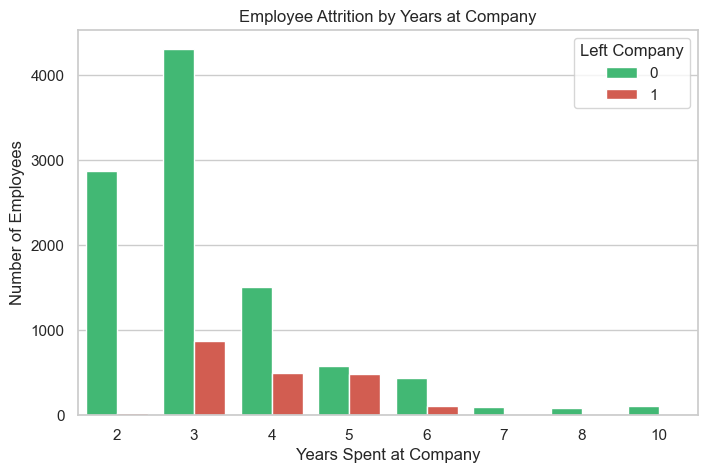

In [15]:
# Countplot: Tenure (Time Spent at Company)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='tenure', hue='left', palette=['#2ecc71', '#e74c3c'])
plt.title('Employee Attrition by Years at Company')
plt.xlabel('Years Spent at Company')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company')
plt.savefig('attrition_by_tenure.png', bbox_inches='tight', dpi=300)
plt.show()

### **Key EDA Insights & Discoveries**

By utilizing different visualization techniques, we've uncovered several critical insights into Salifort Motors' turnover problem:

1. **Distinct Attrition Risk Clusters:** 
The scatterplot of Satisfaction vs. Evaluation reveals three highly distinct groups of employees who quit:
   * **The Burned Out (High Eval, Low Satisfaction):** Top performers (`evaluation > 0.8`) whose satisfaction has completely tanked (`< 0.2`). 
   * **The Underperformers (Low Eval, Low Satisfaction):** Employees struggling with poor evaluations (`~0.5`) and poor satisfaction (`~0.4`).
   * **The Ambitious (High Eval, High Satisfaction):** A surprising cluster of top-tier employees (`evaluation > 0.8`) with high satisfaction (`> 0.7`) who leave anyway. These are likely employees finding better opportunities elsewhere.

2. **Workload Imbalances:**
The boxplot highlights a stark workload imbalance. Employees who leave tend to fall into two extremes: 
   * **Underutilized:** Those with exactly 2 projects working very few hours.
   * **Overworked:** Those with 6-7 projects working massive hours (250-300+ per month). 
   * *Insight:* 3 to 4 projects seems to be the "sweet spot" for employee retention.

3. **Critical Tenure Zone:**
The countplot shows a dramatic spike in turnover precisely at years **3, 4, and 5**. Employees with less than 3 years or more than 6 years of tenure rarely leave. This suggests a systemic issue with mid-level career progression.

4. **Salary is a Factor, but Not the Only One:**
As expected, employees with "low" salaries quit at the highest rate, while "high" earners rarely quit. However, because the correlation heatmap showed relatively weak linear correlations across the board, we know that turnover is driven by complex, non-linear combinations of factors (like workload + evaluation) rather than compensation alone.

#### **PACE: Construct**

Because our EDA revealed non-linear relationships, a tree-based ensemble model such as a Random Forest Classifier is highly appropriate here. They can handle non-linear relationships, do not require strict scaling, and provide excellent feature importance metrics.

In this stage, we will prepare the data for machine learning by converting categorical variables into numeric formats using one-hot encoding. Then, we will split the dataset into training and testing sets to evaluate our Random Forest Classifier.

In [16]:
# Check for class imbalances
df['left'].value_counts(normalize=True)

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

Looking at the class balancing, we see that employees who left are very much the minority at 16% of total observations, representing a moderate imbalance. 

Even so, **rebalancing will not be performed** as this distribution represents real-world scenario of turnover rates which will allow the model to learn from a practical scenario and prevent overfitting.

In [17]:
# Data Preprocessing
# Convert categorical features ('department' and 'salary) using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['department', 'salary'], drop_first=True)

# Define features (X) and target variable (y)
X = df_encoded.drop('left', axis=1)
y= df_encoded['left']

# Split data into training and testing sets
# Stratify to ensure the proportion of target variable is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

To find the optimal set of hyperparameters for our mode, we will run a grid search cross validation that test each combination of hyperparameters to find the highest performing set.

In [18]:
# Assign a dictionary of hyperparameters to search over:
rf_para = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the classifier
rf = RandomForestClassifier(random_state=42)

For the scoring metric, we will use f1 score as it is the harmonic mean between precision and recall, ensuring the model minimizes both false positive and false negatives.

In [19]:
%%time

# Instantiate the GridSearch
rf_cv = GridSearchCV(rf, rf_para, scoring=scoring, cv=5, refit="f1")

# Fit the model
rf_cv.fit(X_train, y_train)

CPU times: total: 1min 1s
Wall time: 1min 1s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [20]:
# Examine the best f1 score
rf_cv.best_score_

np.float64(0.9444707622756816)

In [21]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}

From the grid search results, we can see that a random forest with a max depth of 15, mine_samples_leaf of 1, and min_samples_split of 10 produces the maximum f1 score for this dataset at 0.95 which indicates excellent predictive performance. We will proceed to use this specific model on the test set.

In [22]:
# Use the random forest "best estimator" model to get predictions on the test set
y_pred = rf_cv.best_estimator_.predict(X_test)

#### **PACE: Execute**
We evaluate the model's performance using standard classification metrics. Since the cost of missing an employee who might leave is high, we will pay close attention to the **Recall** metric, alongside overall Accuracy.

In [23]:
# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



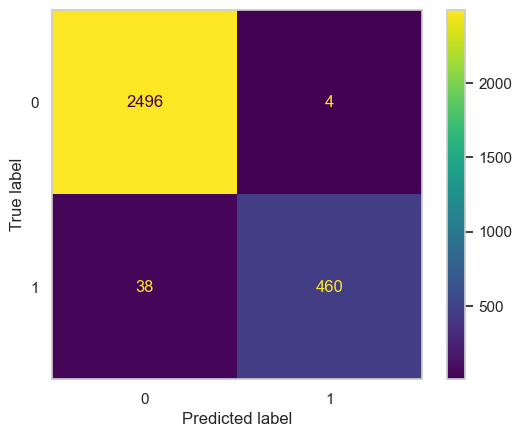

In [24]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred,labels=rf_cv.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.best_estimator_.classes_)
disp.plot(values_format='')
plt.grid(False) 
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

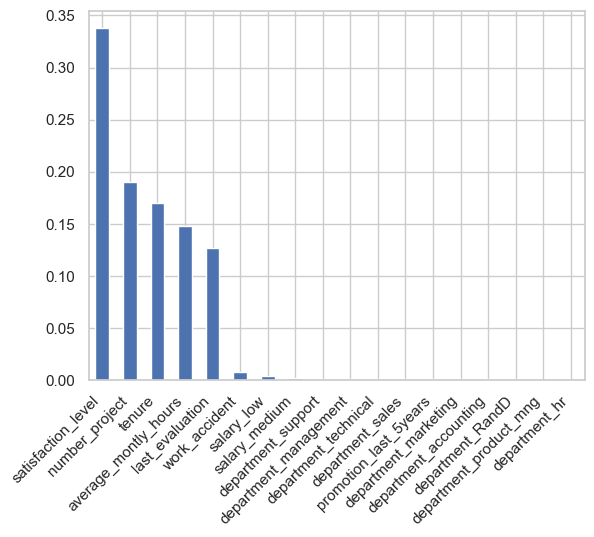

In [25]:
# Extract feature importances
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Visualize feature importances
fig, ax = plt.subplots()
rf_importances.plot.bar(ax=ax)
plt.xticks(rotation=45, ha='right')
plt.savefig('feature_importances.png', bbox_inches='tight', dpi=300)
plt.show()


#### Summary of Model Results

The Random Forest Classifier performed exceptionally well, demonstrating strong predictive power and high reliability for HR deployment.

* **Accuracy (99%):** The model correctly predicted employee outcomes (stayed vs. left) for 99% of the test set. 
* **Precision (99%):** When the model flags an employee as a likely to leave, it is correct 99% of the time. Looking at the confusion matrix, there were only **4 False Positives** 3,000 test cases. This means HR can confidently allocate resources to these flagged individuals without wasting time on employees who are securely retained.
* **Recall (92%):** The model successfully identified 460 out of the 498 employees who actually left. While it missed 38 employees (**False Negatives**), capturing 92% of the total attrition pool provides HR with a massive advantage over their current reactive strategy.
* **Primary Drivers of Turnover:** The feature importance chart decisively highlights that employee sentiment and workload are the root causes of attrition. 
    1. `satisfaction_level` is by far the strongest predictor.
    2. Workload and tenure (`number_project`, `time_spend_company`, and `average_montly_hours`) make up the next critical tier. 
    3. Notably, compensation (`salary`) and the specific `Department` hold virtually zero predictive weight compared to how employees feel about their daily work and project load.

#### Conclusion, Recommendations, and Next Steps

**Conclusion:**
The narrative within the data is clear: Salifort Motors does not have a departmental issue or a primary compensation issue; it has a burnout and engagement issue. Turnover is heavily concentrated among employees experiencing extreme workloads (both over-utilized and under-utilized) and those crossing the 3-to-5-year tenure threshold. The predictive model built here is highly capable of identifying these at-risk employees before they submit their resignations.

**Strategic Recommendations for HR:**
1. **Model Deployment:** Implement this Random Forest model to run monthly against current employee data. HR should prioritize outreach to the individuals flagged by the model, as the 99% precision rate indicates they are highly likely to leave.
2. **Cap Active Projects:** Since `number_project` and `average_montly_hours` are top drivers, management must enforce workload boundaries. Implement an alert system for managers when an employee's project count exceeds 5 or their monthly hours consistently breach the 250-hour mark. 
3. **Overhaul the Review Cycle:** `satisfaction_level` and `last_evaluation` dictate retention more than salary. Annual reviews are too slow. Transition to quarterly "pulse checks" to catch dipping satisfaction levels early, particularly for top performers who may be experiencing burnout.
4. **Target the 3-5 Year Cohort:** Tenure is a massive indicator of turnover. HR should design specific retention pathways, such as leadership training, sabbatical options, or title promotions, targeted specifically at employees entering their third year of service.

**Next Steps & Future Work:**
* **Model Deployment:** Package the model using a pipeline (e.g., standardizing the data ingestion of new HR records) to provide a monthly dashboard for the HR executive team.
* **Cost-Benefit Analysis:** Calculate the estimated financial savings. By multiplying the average cost of replacing an employee by the 460 true positive predictions, we can quantify the exact ROI of deploying this machine learning model.
* **Investigate Satisfaction:** Conduct qualitative research (focus groups or exit interviews) specifically designed to understand *why* the satisfaction levels of high-performing employees are dropping.